# Pricing structure comparisons
Notebook 04 originally used a severity-based curve to convert decline risk into a fixed-fee recommendation. This notebook compares that approach with four alternatives to see whether another curve performs better.

Curve fitting uses out-of-fold predictions from the training data. The hold-out sample is then used to compare the five approaches:

- Severity - the original severity-based approach.
- Risk-only linear - fixed-fee share increases linearly with risk.
- Logistic - midpoint and steepness are tuned on training data.
-  Quantile step - five fixed-fee tiers based on training risk quintiles.
-  Hard threshold - clients move directly from the fee floor to the ceiling at one risk cutoff.

Method E was added after the logistic optimisation kept moving towards a very steep curve. The aim here is to compare the alternatives and decide which is most useful for the final pricing model.

## 1. Setup


In [1]:

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')

## 2. Configuration

In [3]:
DATA_PATH = Path(r"C:\Users\ian.forbes\FinalProject\processed\modelling_dataset_jan25.csv")
OUT_DIR   = Path(r"C:\Users\ian.forbes\FinalProject\outputs\pricing_curve_comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.30
TARGET       = "target_decline"
N_SPLITS     = 5
YOUNG_THRESHOLD_MONTHS = 15
MIN_BAND_N_FOR_CEILING = 50
N_BOOTSTRAP = 1000

PUBLISHER_FEATURES = [
    "pub_share_lower_2024", "pub_share_mid_2024", "pub_share_upper_2024",
    "pub_share_technical_2024", "pub_funnel_diversity",
    "pub_lower_funnel_shift_yoy", "pub_mid_funnel_shift_yoy",
    "pub_upper_funnel_shift_yoy", "has_pub_data",
]
FIRMOGRAPHIC_FEATURES = [
    "log_commission_l12m", "log_core_gp_l12m", "etr_mean_l12m",
    "fixed_fee_share_mean_l12m", "zero_commission_months",
    "active_months_l12m", "programme_age_months", "programme_count",
    "partially_closed_last_12m", "former_sas_flag", "is_exclusive",
    "has_cpi_flag", "platform_rank", "service_rank", "commission_size_tier_code",
]
MOMENTUM_FEATURES = [
    "momentum_3m_yoy", "momentum_3m_yoy_missing",
    "negative_growth_months_l12m", "consecutive_declining_months",
    "commission_cv_l12m",
    "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy",
    "momentum_q2_yoy_missing", "momentum_q3_yoy_missing", "momentum_q4_yoy_missing",
    "accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
    "worsening_negative_trend", "recent_reversal_to_decline",
]
FULL_FEATURES = FIRMOGRAPHIC_FEATURES + MOMENTUM_FEATURES + PUBLISHER_FEATURES

rf_params = dict(n_estimators=500, min_samples_leaf=20, max_features="sqrt",
                 n_jobs=-1, random_state=RANDOM_STATE)
xgb_params = dict(n_estimators=500, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)

## 3. Data preparation and scope split

The dataset is rebuilt using the same feature and scope definitions as the earlier modelling notebooks. I also recreate the severity target because Method A needs it (see 03 for full details if needed)

In [4]:
print(f"Loading {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[df["commission_l12m"] > 0].copy()

tier_bins   = [-np.inf, 1_000, 10_000, 100_000, 1_000_000, np.inf]
tier_labels = ["micro", "small", "mid", "large", "strategic"]
df["commission_size_tier"]      = pd.cut(df["commission_l12m"], bins=tier_bins, labels=tier_labels)
df["commission_size_tier_code"] = df["commission_size_tier"].cat.codes
df["log_commission_l12m"] = np.log1p(df["commission_l12m"].clip(lower=0))
df["log_core_gp_l12m"]    = np.log1p(df["core_gp_l12m"].clip(lower=0))

df["momentum_3m_yoy_missing"] = df["momentum_3m_yoy"].isna().astype(int)
df["momentum_3m_yoy"]         = df["momentum_3m_yoy"].fillna(0)
df["commission_cv_l12m"]        = df["commission_cv_l12m"].fillna(0)
df["fixed_fee_share_mean_l12m"] = df["fixed_fee_share_mean_l12m"].fillna(0)
df["programme_age_months"]      = df["programme_age_months"].fillna(df["programme_age_months"].median())
df["etr_mean_l12m"]             = df["etr_mean_l12m"].fillna(df["etr_mean_l12m"].median())
for col in ["momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[f"{col}_missing"] = df[col].isna().astype("int8")
for col in PUBLISHER_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df = df[df[TARGET].notna()].copy()
df[TARGET] = df[TARGET].astype(int)

q1, yoy_12m = df["momentum_q1_yoy"], df["commission_yoy_growth"]
df["worsening_negative_trend"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m < 0) & (q1 < yoy_12m)
).astype("int8")
df["recent_reversal_to_decline"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m >= 0)
).astype("int8")
if "accel_q2_to_q1" not in df.columns:
    df["accel_q2_to_q1"] = df["momentum_q1_yoy"] - df["momentum_q2_yoy"]
if "accel_q3_to_q2" not in df.columns:
    df["accel_q3_to_q2"] = df["momentum_q2_yoy"] - df["momentum_q3_yoy"]
if "accel_q4_to_q3" not in df.columns:
    df["accel_q4_to_q3"] = df["momentum_q3_yoy"] - df["momentum_q4_yoy"]
for c in ["accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
          "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[c] = df[c].fillna(0)

df["scope_segment"] = np.select(
    [
        df["momentum_3m_yoy_missing"] == 0,
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] < YOUNG_THRESHOLD_MONTHS),
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] >= YOUNG_THRESHOLD_MONTHS),
    ],
    ["in_scope", "excluded_too_young", "fallback_established_sparse"],
    default="unclassified",
)
df_in_scope = df[df["scope_segment"] == "in_scope"].copy()

df_in_scope["pct_change"] = (
    (df_in_scope["commission_forward_12m"] - df_in_scope["commission_l12m"])
    / df_in_scope["commission_l12m"]
)
df_in_scope["severity_target"] = df_in_scope["pct_change"].clip(lower=-0.95, upper=3.0)

train_df, test_df = train_test_split(
    df_in_scope, test_size=TEST_SIZE, stratify=df_in_scope[TARGET], random_state=RANDOM_STATE
)
print(f"In-scope: {len(df_in_scope):,}  Train: {len(train_df):,}  Test: {len(test_df):,}")

Loading C:\Users\ian.forbes\FinalProject\processed\modelling_dataset_jan25.csv
In-scope: 10,578  Train: 7,404  Test: 3,174


## 4. Risk scores for curves
Curve fitting uses out-of-fold risk scores for the training data. After the classifier is chosen from training OOF AUC, it is refitted on the full training set and used to score the hold-out sample.

This keeps curve fitting separate from the hold-out comparison.

In [5]:
def make_estimator(algo):
    if algo == "logistic":
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                                                     max_iter=1000, random_state=RANDOM_STATE))])
    if algo == "rf":
        return RandomForestClassifier(**rf_params)
    if algo == "xgb":
        return XGBClassifier(**xgb_params)
    raise ValueError(algo)

Xtr, Xte = train_df[FULL_FEATURES], test_df[FULL_FEATURES]
y_train = train_df[TARGET].values

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_scores = {}
for algo in ["logistic", "rf", "xgb"]:
    oof = np.zeros(len(y_train))
    for tr_idx, va_idx in skf.split(Xtr, y_train):
        est = make_estimator(algo)
        est.fit(Xtr.iloc[tr_idx], y_train[tr_idx])
        oof[va_idx] = est.predict_proba(Xtr.iloc[va_idx])[:, 1]
    auc = roc_auc_score(y_train, oof)
    oof_scores[algo] = (oof, auc)
    print(f"  {algo:>8}: train OOF AUC = {auc:.4f}")

best_algo = max(oof_scores, key=lambda a: oof_scores[a][1])
train_oof_risk, best_oof_auc = oof_scores[best_algo]
train_df = train_df.copy()
train_df["risk_score"] = train_oof_risk
print(f"\nSelected algorithm: {best_algo} (OOF AUC = {best_oof_auc:.4f})")

final_est = make_estimator(best_algo)
final_est.fit(Xtr, y_train)
test_df = test_df.copy()
test_df["risk_score"] = final_est.predict_proba(Xte)[:, 1]
test_auc = roc_auc_score(test_df[TARGET].values, test_df["risk_score"])
print(f"Hold-out AUC: {test_auc:.4f}")

c:\Users\ian.forbes\FinalProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ian.forbes\FinalProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\ian.forbes\FinalProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

  logistic: train OOF AUC = 0.6434
        rf: train OOF AUC = 0.6572
       xgb: train OOF AUC = 0.6414

Selected algorithm: rf (OOF AUC = 0.6572)
Hold-out AUC: 0.6637


## 5. Training calibration bands

Risk bands are built from the OOF training predictions. Method A uses their observed severity values.

In [6]:
bins = np.arange(0, 1.01, 0.10)
labels = [f"{int(b*100)}-{int((b+0.10)*100)}%" for b in bins[:-1]]
band_midpoints = {labels[i]: (bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)}

train_df["risk_band"] = pd.cut(train_df["risk_score"], bins=bins, labels=labels, include_lowest=True)
train_bands = train_df.groupby("risk_band", observed=True).agg(
    account_count=("risk_score", "count"),
    actual_decline_rate=(TARGET, "mean"),
    mean_actual_severity=("severity_target", "mean"),
).reset_index()
train_bands["risk_band_midpoint"] = train_bands["risk_band"].map(band_midpoints)
train_bands = train_bands.sort_values("risk_band_midpoint").reset_index(drop=True)
print("\nTrain-based (OOF) calibration bands - built entirely without touching test:")
print(train_bands.round(4).to_string(index=False))

eligible = train_bands[train_bands["account_count"] >= MIN_BAND_N_FOR_CEILING]
if len(eligible) == 0:
    raise ValueError(f"No train band has >= {MIN_BAND_N_FOR_CEILING} accounts.")
ceiling_band = eligible.loc[eligible["risk_band_midpoint"].idxmax()]

FEE_FLOOR   = float(train_df["fixed_fee_share_mean_l12m"].quantile(0.25))
FEE_CEILING = float(ceiling_band["actual_decline_rate"])
print(f"\nFloor = {FEE_FLOOR:.1%} (25th pct actual historical fixed-fee share, train)")
print(f"Ceiling = {FEE_CEILING:.1%} (train band '{ceiling_band['risk_band']}', "
      f"n={ceiling_band['account_count']:.0f})")


Train-based (OOF) calibration bands - built entirely without touching test:
risk_band  account_count  actual_decline_rate  mean_actual_severity risk_band_midpoint
   20-30%            221               0.2760                0.4973               0.25
   30-40%           1455               0.3478                0.3934               0.35
   40-50%           2003               0.4358                0.2378               0.45
   50-60%           1699               0.5427                0.0718               0.55
   60-70%           1505               0.6698               -0.1225               0.65
   70-80%            513               0.7641               -0.3160               0.75
   80-90%              8               0.7500               -0.4578               0.85

Floor = 0.0% (25th pct actual historical fixed-fee share, train)
Ceiling = 76.4% (train band '70-80%', n=513)


## Backtest functions

The same backtest functions are used for every curve so that only the fee-curve shape changes between methods.

In [7]:
def prep_backtest_frame(frame):
    """Reconstruct baseline (actual) terms once per population."""
    f = frame.copy()
    f = f[f["commission_forward_12m"].notna()].copy()
    f["baseline_commission"] = f["commission_l12m"]
    f["baseline_gp"]         = f["core_gp_l12m"]
    f["baseline_fixed_eur"]  = f["fixed_fee_share_mean_l12m"] * f["baseline_gp"]
    f["baseline_variable_rate"] = (
        (f["baseline_gp"] - f["baseline_fixed_eur"]) / f["baseline_commission"]
    ).clip(lower=0)
    return f

def apply_fee_curve(frame, fee_curve_fn):
    """Apply a fee curve function and return new terms and resulting GP on realised forward commission."""
    f = frame.copy()
    f["new_fixed_pct_of_gp"] = np.clip(fee_curve_fn(f["risk_score"].values), 0, 1)
    f["new_fixed_eur"] = f["new_fixed_pct_of_gp"] * f["baseline_gp"]
    f["new_variable_rate"] = (
        (f["baseline_gp"] - f["new_fixed_eur"]) / f["baseline_commission"]
    ).clip(lower=0)
    fwd = f["commission_forward_12m"]
    f["old_gp_forward"] = f["baseline_fixed_eur"] + f["baseline_variable_rate"] * fwd
    f["new_gp_forward"] = f["new_fixed_eur"] + f["new_variable_rate"] * fwd
    f["gp_delta"] = f["new_gp_forward"] - f["old_gp_forward"]
    f["actual_direction"] = np.where(fwd < f["baseline_commission"] * 0.9, "decline",
                              np.where(fwd > f["baseline_commission"], "growth", "flat"))
    return f

def backtest_summary(f):
    total_old = f["old_gp_forward"].sum()
    total_delta = f["gp_delta"].sum()
    by_dir = f.groupby("actual_direction")["gp_delta"].sum()
    by_dir_old = f.groupby("actual_direction")["old_gp_forward"].sum()
    return {
        "gp_delta_pct": total_delta / total_old * 100,
        "decline_delta_pct": (by_dir.get("decline", 0) / by_dir_old.get("decline", np.nan)) * 100,
        "growth_delta_pct": (by_dir.get("growth", 0) / by_dir_old.get("growth", np.nan)) * 100,
        "total_delta_eur": total_delta,
    }

train_bt_base = prep_backtest_frame(train_df)
test_bt_base  = prep_backtest_frame(test_df)

## 7. Candidate fee curves
Five approaches are compared:
- A Severity: the original curve, fitted to training risk-band severity.
- B Risk-only linear: fixed-fee share rises linearly with risk.
- C Logistic: midpoint and steepness are tuned using the training backtest.
- D Quantile step: five fee tiers based on training risk quintiles.
- E Hard threshold: floor below one risk cutoff and ceiling above it.

Method E was added after the unconstrained logistic search repeatedly moved towards a very steep curve.

In [8]:
from sklearn.isotonic import IsotonicRegression

# Method A: severity-based isotonic curve
iso = IsotonicRegression(increasing=False, out_of_bounds="clip")
iso.fit(
    train_bands["risk_band_midpoint"],
    train_bands["mean_actual_severity"]
)

sev_min = iso.predict([0.0])[0]
sev_max = iso.predict([1.0])[0]


def curve_isotonic_severity(risk):
    expected_sev = iso.predict(np.atleast_1d(risk))
    denom = (sev_min - sev_max) if (sev_min - sev_max) != 0 else 1.0
    normalised = np.clip((sev_min - expected_sev) / denom, 0, 1)
    return FEE_FLOOR + (FEE_CEILING - FEE_FLOOR) * normalised


# Method B: simple linear relationship between risk and fixed-fee share
def curve_risk_linear(risk):
    return FEE_FLOOR + (FEE_CEILING - FEE_FLOOR) * np.clip(risk, 0, 1)


# Method C: logistic curve
def make_logistic_curve(midpoint, steepness):
    def curve(risk):
        risk = np.asarray(risk)
        s = 1 / (1 + np.exp(-steepness * (risk - midpoint)))
        return FEE_FLOOR + (FEE_CEILING - FEE_FLOOR) * s
    return curve


# Method E: hard threshold
def make_hard_threshold_curve(midpoint):
    def curve(risk):
        risk = np.asarray(risk)
        return np.where(risk < midpoint, FEE_FLOOR, FEE_CEILING)
    return curve


# Percentage of clients close to either fee extreme
SATURATION_TOL = 0.02

def saturation_share(fee_curve_fn, risk_scores, tol=SATURATION_TOL):
    fee = np.clip(fee_curve_fn(risk_scores), 0, 1)
    saturated = (fee <= FEE_FLOOR + tol) | (fee >= FEE_CEILING - tol)
    return saturated.mean() * 100


# ---------------------------------------------------------------------
# Unconstrained logistic grid search
# ---------------------------------------------------------------------

print("\n" + "=" * 80)
print("GRID SEARCH - optimised logistic curve (fit on TRAIN only)")
print("=" * 80)

midpoints = np.arange(0.40, 0.66, 0.01)
steepness_values = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000]

train_risk_scores = train_bt_base["risk_score"].values

best_score = -np.inf
best_params = None
grid_results = []

for midpoint in midpoints:
    for steepness in steepness_values:
        candidate = make_logistic_curve(midpoint, steepness)
        bt = apply_fee_curve(train_bt_base, candidate)
        score = backtest_summary(bt)["gp_delta_pct"]
        sat_pct = saturation_share(candidate, train_risk_scores)

        grid_results.append({
            "midpoint": float(midpoint),
            "steepness": steepness,
            "gp_delta_pct": score,
            "saturation_pct": sat_pct
        })

        if score > best_score:
            best_score = score
            best_params = (midpoint, steepness)

print(
    f"Best params (unconstrained): midpoint={best_params[0]:.4f}, "
    f"steepness={best_params[1]} "
    f"(train GP delta = {best_score:+.3f}%)"
)

curve_optimised_logistic = make_logistic_curve(*best_params)

grid_results_df = pd.DataFrame(grid_results)

print("\nTop logistic parameter combinations (unconstrained):")
display(
    grid_results_df
    .sort_values("gp_delta_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Method E: hard-threshold comparison
# ---------------------------------------------------------------------

best_threshold_score = -np.inf
best_threshold_midpoint = None
threshold_results = []

for midpoint in midpoints:
    threshold_curve = make_hard_threshold_curve(midpoint)
    bt = apply_fee_curve(train_bt_base, threshold_curve)
    score = backtest_summary(bt)["gp_delta_pct"]

    threshold_results.append({
        "midpoint": float(midpoint),
        "gp_delta_pct": score
    })

    if score > best_threshold_score:
        best_threshold_score = score
        best_threshold_midpoint = midpoint

print(
    f"\nHard-threshold diagnostic: midpoint={best_threshold_midpoint:.4f} "
    f"(train GP delta = {best_threshold_score:+.3f}%)"
)

print(
    "Difference between best unconstrained logistic and hard threshold: "
    f"{best_score - best_threshold_score:+.3f} percentage points"
)


# ---------------------------------------------------------------------
# Method D: quantile-step curve
# ---------------------------------------------------------------------

train_quintile_cuts = train_df["risk_score"].quantile([0.2, 0.4, 0.6, 0.8]).values
tier_fees = np.linspace(FEE_FLOOR, FEE_CEILING, 5)


def curve_quantile_step(risk):
    risk = np.atleast_1d(risk)
    tier_idx = np.searchsorted(train_quintile_cuts, risk, side="right")
    return tier_fees[tier_idx]


print(
    "\nMethod D quantile cutoffs: "
    f"{[round(float(c), 4) for c in train_quintile_cuts]}"
)

print(
    "Method D tier fees: "
    f"{[round(float(f), 4) for f in tier_fees]}"
)

D_SATURATION_PCT = saturation_share(
    curve_quantile_step,
    train_risk_scores
)

print(
    f"Method D share of train clients within two percentage points "
    f"of either fee extreme: {D_SATURATION_PCT:.1f}%"
)


# Initial method set.
# Method C is replaced by the constrained logistic curve in the next section.
methods = {
    "A_isotonic_severity": curve_isotonic_severity,
    "B_risk_only_linear": curve_risk_linear,
    "C_optimised_logistic": curve_optimised_logistic,
    "D_quantile_step": curve_quantile_step,
    "E_hard_threshold": make_hard_threshold_curve(best_threshold_midpoint),
}


GRID SEARCH - optimised logistic curve (fit on TRAIN only)
Best params (unconstrained): midpoint=0.5200, steepness=750 (train GP delta = +4.738%)

Top logistic parameter combinations (unconstrained):


,midpoint,steepness,gp_delta_pct,saturation_pct
0,0.52,750,4.738109,97.690438
1,0.52,500,4.736392,96.515397
2,0.52,1000,4.734078,98.311723
3,0.52,300,4.717458,94.354403
4,0.53,1000,4.708086,98.352242
5,0.53,750,4.705649,97.811994
6,0.53,500,4.699913,96.704484
7,0.52,200,4.688780,91.247974
8,0.53,300,4.687282,94.516478
9,0.53,200,4.668169,91.720692



Hard-threshold diagnostic: midpoint=0.5300 (train GP delta = +4.712%)
Difference between best unconstrained logistic and hard threshold: +0.026 percentage points

Method D quantile cutoffs: [0.3907, 0.4627, 0.5432, 0.632]
Method D tier fees: [0.0, 0.191, 0.3821, 0.5731, 0.7641]
Method D share of train clients within two percentage points of either fee extreme: 40.0%


### Choosing the steepness

I expected the logistic search to settle on a moderately steep curve, but the best result kept moving towards the top of the grid. Extending the search confirmed that it was effectively trying to become a threshold.

I therefore tested the threshold directly as Method E. This performed well, but stakeholder feedback raised two practical problems: little negotiating room around the cutoff, and no distinction between a borderline and very high-risk client.

My first attempt was to allow curves within a small GP tolerance of the optimum, but these were still very steep. I therefore used the share of clients close to either pricing extreme as a constraint instead. Method D naturally places 40% of clients at the two extremes, so I use this as the maximum for Method C.

The selected logistic curve is the highest-training-GP combination that stays within that cap.

,steepness,midpoint,gp_delta_pct,saturation_pct
0,5,0.65,1.196270,0.000000
1,10,0.58,2.503928,0.000000
2,15,0.55,3.310609,4.349001
3,20,0.53,3.786423,15.397083
4,30,0.52,4.228114,40.491626
5,50,0.52,4.473110,64.802809
6,75,0.52,4.561471,76.661264
7,100,0.52,4.607761,82.685035
8,150,0.52,4.660312,88.182064
9,200,0.52,4.688780,91.247974


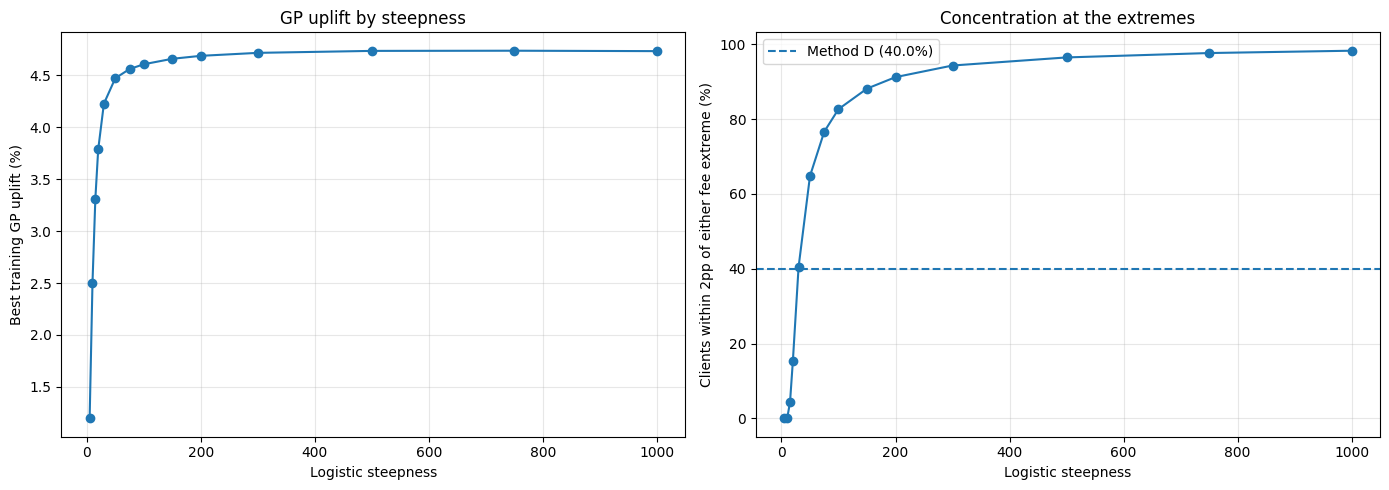

Concentration cap: 40.0%
Selected curve: midpoint=0.51, steepness=30
Training GP uplift: +4.214%
Clients within 2pp of either extreme: 39.9%
GP difference vs unconstrained optimum: 0.525 percentage points

Fee recommendation at illustrative risk scores:


,risk_score,C_logistic_fee_pct,D_quantile_step_fee_pct,E_hard_threshold_fee_pct
0,0.40,2.72,19.10,0.00
1,0.45,10.84,19.10,0.00
2,0.50,32.52,38.21,0.00
3,0.55,58.73,57.31,76.41
4,0.60,71.60,57.31,76.41
5,0.65,75.28,76.41,76.41
6,0.70,76.16,76.41,76.41
7,0.80,76.40,76.41,76.41


In [9]:
# Summarise the best-GP midpoint at each steepness for the diagnostic chart
steepness_summary = (
    grid_results_df
    .sort_values("gp_delta_pct", ascending=False)
    .groupby("steepness", as_index=False)
    .first()
    .sort_values("steepness")
    .reset_index(drop=True)
)

display(
    steepness_summary[
        ["steepness", "midpoint", "gp_delta_pct", "saturation_pct"]
    ]
)


# Show what happens as the logistic curve becomes steeper
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    steepness_summary["steepness"],
    steepness_summary["gp_delta_pct"],
    marker="o"
)
axes[0].set_xlabel("Logistic steepness")
axes[0].set_ylabel("Best training GP uplift (%)")
axes[0].set_title("GP uplift by steepness")
axes[0].grid(alpha=0.3)

axes[1].plot(
    steepness_summary["steepness"],
    steepness_summary["saturation_pct"],
    marker="o"
)
axes[1].axhline(
    D_SATURATION_PCT,
    linestyle="--",
    label=f"Method D ({D_SATURATION_PCT:.1f}%)"
)
axes[1].set_xlabel("Logistic steepness")
axes[1].set_ylabel("Clients within 2pp of either fee extreme (%)")
axes[1].set_title("Concentration at the extremes")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Apply the concentration constraint to all midpoint/steepness combinations
eligible_grid = grid_results_df[
    grid_results_df["saturation_pct"] <= D_SATURATION_PCT
].copy()

if eligible_grid.empty:
    raise ValueError(
        "No logistic curve satisfies the concentration constraint. "
        "The grid would need to be extended towards lower steepness values."
    )

# Highest training GP uplift among the curves that meet the constraint
selected_row = eligible_grid.loc[
    eligible_grid["gp_delta_pct"].idxmax()
]

SELECTED_MIDPOINT = float(selected_row["midpoint"])
SELECTED_STEEPNESS = int(selected_row["steepness"])
SELECTED_GP_DELTA = float(selected_row["gp_delta_pct"])
SELECTED_SATURATION_PCT = float(selected_row["saturation_pct"])

unconstrained_max = grid_results_df["gp_delta_pct"].max()
gp_sacrifice = unconstrained_max - SELECTED_GP_DELTA

print(f"Concentration cap: {D_SATURATION_PCT:.1f}%")
print(
    f"Selected curve: midpoint={SELECTED_MIDPOINT:.2f}, "
    f"steepness={SELECTED_STEEPNESS}"
)
print(f"Training GP uplift: {SELECTED_GP_DELTA:+.3f}%")
print(f"Clients within 2pp of either extreme: {SELECTED_SATURATION_PCT:.1f}%")
print(f"GP difference vs unconstrained optimum: {gp_sacrifice:.3f} percentage points")


# Replace the unconstrained Method C with the selected constrained curve
curve_selected_logistic = make_logistic_curve(
    SELECTED_MIDPOINT,
    SELECTED_STEEPNESS
)

methods["C_optimised_logistic"] = curve_selected_logistic


# Simple sanity check: what would C, D and E recommend at the same risk scores?
spot_check_risks = np.array([
    0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70, 0.80
])

spot_check = pd.DataFrame({
    "risk_score": spot_check_risks,
    "C_logistic_fee_pct": curve_selected_logistic(spot_check_risks) * 100,
    "D_quantile_step_fee_pct": curve_quantile_step(spot_check_risks) * 100,
    "E_hard_threshold_fee_pct": methods["E_hard_threshold"](spot_check_risks) * 100
})

print("\nFee recommendation at illustrative risk scores:")
display(spot_check.round(2))


## 8. Evaluating the methods

All five methods are now applied to the hold-out sample. Training results are also shown for context.

I use bootstrap confidence intervals around the hold-out GP uplift to show the uncertainty around each point estimate.

In [10]:
def bootstrap_ci(frame, fee_curve_fn, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    bt = apply_fee_curve(frame, fee_curve_fn)
    n = len(bt)
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = bt.iloc[idx]
        deltas[i] = sample["gp_delta"].sum() / sample["old_gp_forward"].sum() * 100
    return np.quantile(deltas, [0.025, 0.975])

results = []
for name, fn in methods.items():
    train_bt = apply_fee_curve(train_bt_base, fn)
    test_bt  = apply_fee_curve(test_bt_base, fn)
    train_summary = backtest_summary(train_bt)
    test_summary  = backtest_summary(test_bt)
    ci_lo, ci_hi = bootstrap_ci(test_bt_base, fn)
    results.append({
        "method": name,
        "train_gp_delta_pct": train_summary["gp_delta_pct"],
        "test_gp_delta_pct":  test_summary["gp_delta_pct"],
        "test_ci_lo": ci_lo, "test_ci_hi": ci_hi,
        "test_decline_delta_pct": test_summary["decline_delta_pct"],
        "test_growth_delta_pct":  test_summary["growth_delta_pct"],
    })
    print(f"\n{name}:")
    print(f"  Train GP delta: {train_summary['gp_delta_pct']:+.3f}%   "
          f"Test GP delta: {test_summary['gp_delta_pct']:+.3f}%  "
          f"[95% CI {ci_lo:+.3f}%, {ci_hi:+.3f}%]")
    print(f"  Test mirror check - decline: {test_summary['decline_delta_pct']:+.3f}%   "
          f"growth: {test_summary['growth_delta_pct']:+.3f}%")

res_df = pd.DataFrame(results).round(4)
res_df.to_csv(OUT_DIR / "curve_method_comparison.csv", index=False)

print("COMPARISON TABLE - all methods")
print(res_df.to_string(index=False))


A_isotonic_severity:
  Train GP delta: +2.288%   Test GP delta: +2.426%  [95% CI +0.564%, +4.203%]
  Test mirror check - decline: +13.085%   growth: -2.573%

B_risk_only_linear:
  Train GP delta: +0.308%   Test GP delta: +1.027%  [95% CI -1.156%, +3.054%]
  Test mirror check - decline: +17.197%   growth: -7.202%

C_optimised_logistic:
  Train GP delta: +4.214%   Test GP delta: +3.816%  [95% CI +0.930%, +6.478%]
  Test mirror check - decline: +16.895%   growth: -2.105%

D_quantile_step:
  Train GP delta: +3.903%   Test GP delta: +3.322%  [95% CI +0.879%, +5.708%]
  Test mirror check - decline: +18.231%   growth: -3.664%

E_hard_threshold:
  Train GP delta: +4.712%   Test GP delta: +4.264%  [95% CI +1.005%, +7.274%]
  Test mirror check - decline: +15.333%   growth: -0.477%
COMPARISON TABLE - all methods
              method  train_gp_delta_pct  test_gp_delta_pct  test_ci_lo  test_ci_hi  test_decline_delta_pct  test_growth_delta_pct
 A_isotonic_severity              2.2878             2.

## 9. Charts

Fee-curve shapes and hold-out GP uplift for the five methods.

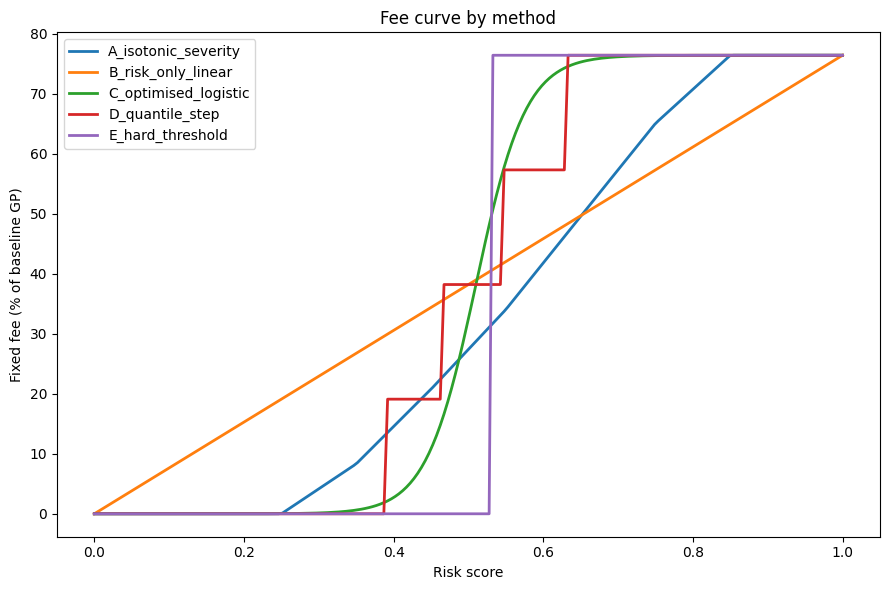

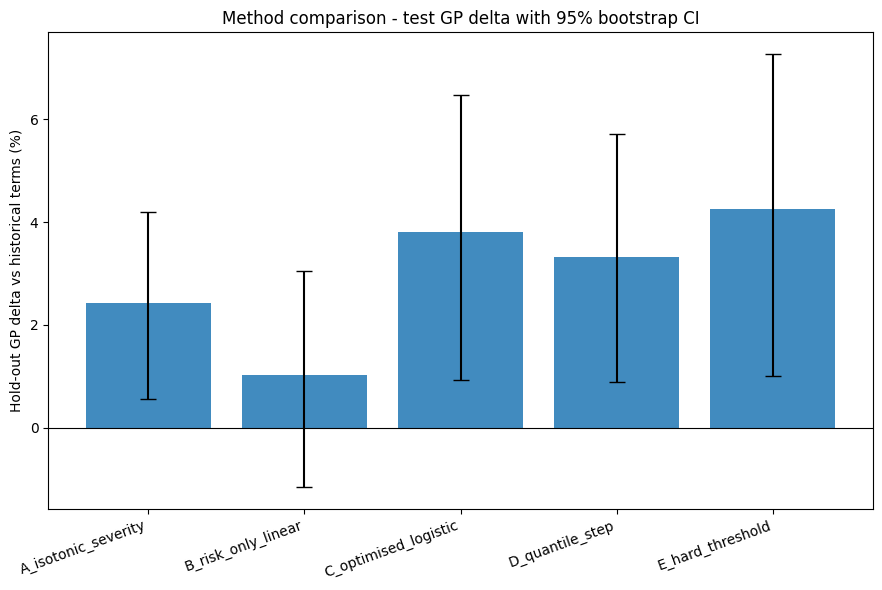

In [11]:
grid = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(9, 6))
for name, fn in methods.items():
    ax.plot(grid, fn(grid) * 100, label=name, linewidth=2)
ax.set_xlabel("Risk score")
ax.set_ylabel("Fixed fee (% of baseline GP)")
ax.set_title("Fee curve by method")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "curve_shapes_comparison.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(res_df))
yerr = [
    (res_df["test_gp_delta_pct"] - res_df["test_ci_lo"]).values,
    (res_df["test_ci_hi"] - res_df["test_gp_delta_pct"]).values,
]
ax.bar(x, res_df["test_gp_delta_pct"], yerr=yerr, capsize=6, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(res_df["method"], rotation=20, ha="right")
ax.set_ylabel("Hold-out GP delta vs historical terms (%)")
ax.set_title("Method comparison - test GP delta with 95% bootstrap CI")
fig.tight_layout()
fig.savefig(OUT_DIR / "method_comparison_with_ci.png", dpi=150)
plt.show()


## 10. Conclusion

The final comparison considers the hold-out GP result alongside how each curve behaves commercially. The confidence intervals are shown as an indication of uncertainty rather than as a formal pairwise significance test.

In [12]:
eligible_methods = res_df[~res_df["method"].str.startswith("E_")]
best_eligible = eligible_methods.loc[
    eligible_methods["test_gp_delta_pct"].idxmax()
]

best_overall = res_df.loc[
    res_df["test_gp_delta_pct"].idxmax()
]

print("Highest hold-out GP point estimate:")
print(
    f"  {best_overall['method']}: "
    f"{best_overall['test_gp_delta_pct']:+.3f}% "
    f"[95% CI {best_overall['test_ci_lo']:+.3f}%, "
    f"{best_overall['test_ci_hi']:+.3f}%]"
)

print("Best method considering business acceptance:")
print(
    f"  {best_eligible['method']}: "
    f"{best_eligible['test_gp_delta_pct']:+.3f}% "
    f"[95% CI {best_eligible['test_ci_lo']:+.3f}%, "
    f"{best_eligible['test_ci_hi']:+.3f}%]"
)



Highest hold-out GP point estimate:
  E_hard_threshold: +4.264% [95% CI +1.005%, +7.274%]
Best method considering business acceptance:
  C_optimised_logistic: +3.816% [95% CI +0.930%, +6.478%]


Method E has the highest observed hold-out GP uplift at 4.26%, while Method C is the strongest of the four business-eligible approaches at 3.82%. Their confidence intervals overlap substantially, so I would not treat the difference as an of E's advantage.

I will use Method C because it provides continuous differentiation across the risk range while remaining within the 40% concentration constraint. The selected curve leaves 39.9% of clients within two percentage points of either pricing extreme, compared with 40% for the quantile-step approach. Its advantage over Method D is therefore the continuous shape rather than materially lower concentration.

The hold-out sample has been used to compare these methods, so this is a method-selection result rather than a final untouched estimate of future performance. A live pilot would still be needed to test how clients actually respond to the revised terms.